# 固定服务名额的区域分配模拟

所有实测结果来自12月独立测试。名额是可服务订单数量，不是真实车辆。

In [1]:
from pathlib import Path
import json
import pandas as pd
ROOT=Path.cwd()
assert (ROOT/'src').exists()
pd.set_option('display.max_columns',20)

In [2]:
from src.simulate import allocate
# 明确标注的算法演示输入，不是业务结果
print('零预测回退与编号并列处理:',allocate([0,0,0],2,[3,1,2]).tolist())

零预测回退与编号并列处理: [0, 1, 1]


In [3]:
summary=pd.read_csv(ROOT/'reports/tables/simulation_summary.csv')
summary[['budget','strategy_label','actual','allocation','served','uncovered','idle','coverage','utilization']]

,budget,strategy_label,actual,allocation,served,uncovered,idle,coverage,utilization
0,500,选定预测方案分配,4297383,372000,364942,3932441,7058,0.084922,0.981027
1,500,四周历史均值分配,4297383,372000,363604,3933779,8396,0.084611,0.977430
2,500,均匀分配,4297383,372000,210997,4086386,161003,0.049099,0.567196
3,1000,选定预测方案分配,4297383,744000,706548,3590835,37452,0.164414,0.949661
4,1000,四周历史均值分配,4297383,744000,702927,3594456,41073,0.163571,0.944794
5,1000,均匀分配,4297383,744000,355427,3941956,388573,0.082708,0.477724
6,2000,选定预测方案分配,4297383,1488000,1325757,2971626,162243,0.308503,0.890966
7,2000,四周历史均值分配,4297383,1488000,1317373,2980010,170627,0.306552,0.885331
8,2000,均匀分配,4297383,1488000,577499,3719884,910501,0.134384,0.388104


In [4]:
assert (summary.served+summary.uncovered==summary.actual).all()
assert (summary.served+summary.idle==summary.allocation).all()
assert (summary.served<=summary.actual).all()
print('需求和名额守恒检查通过')

需求和名额守恒检查通过


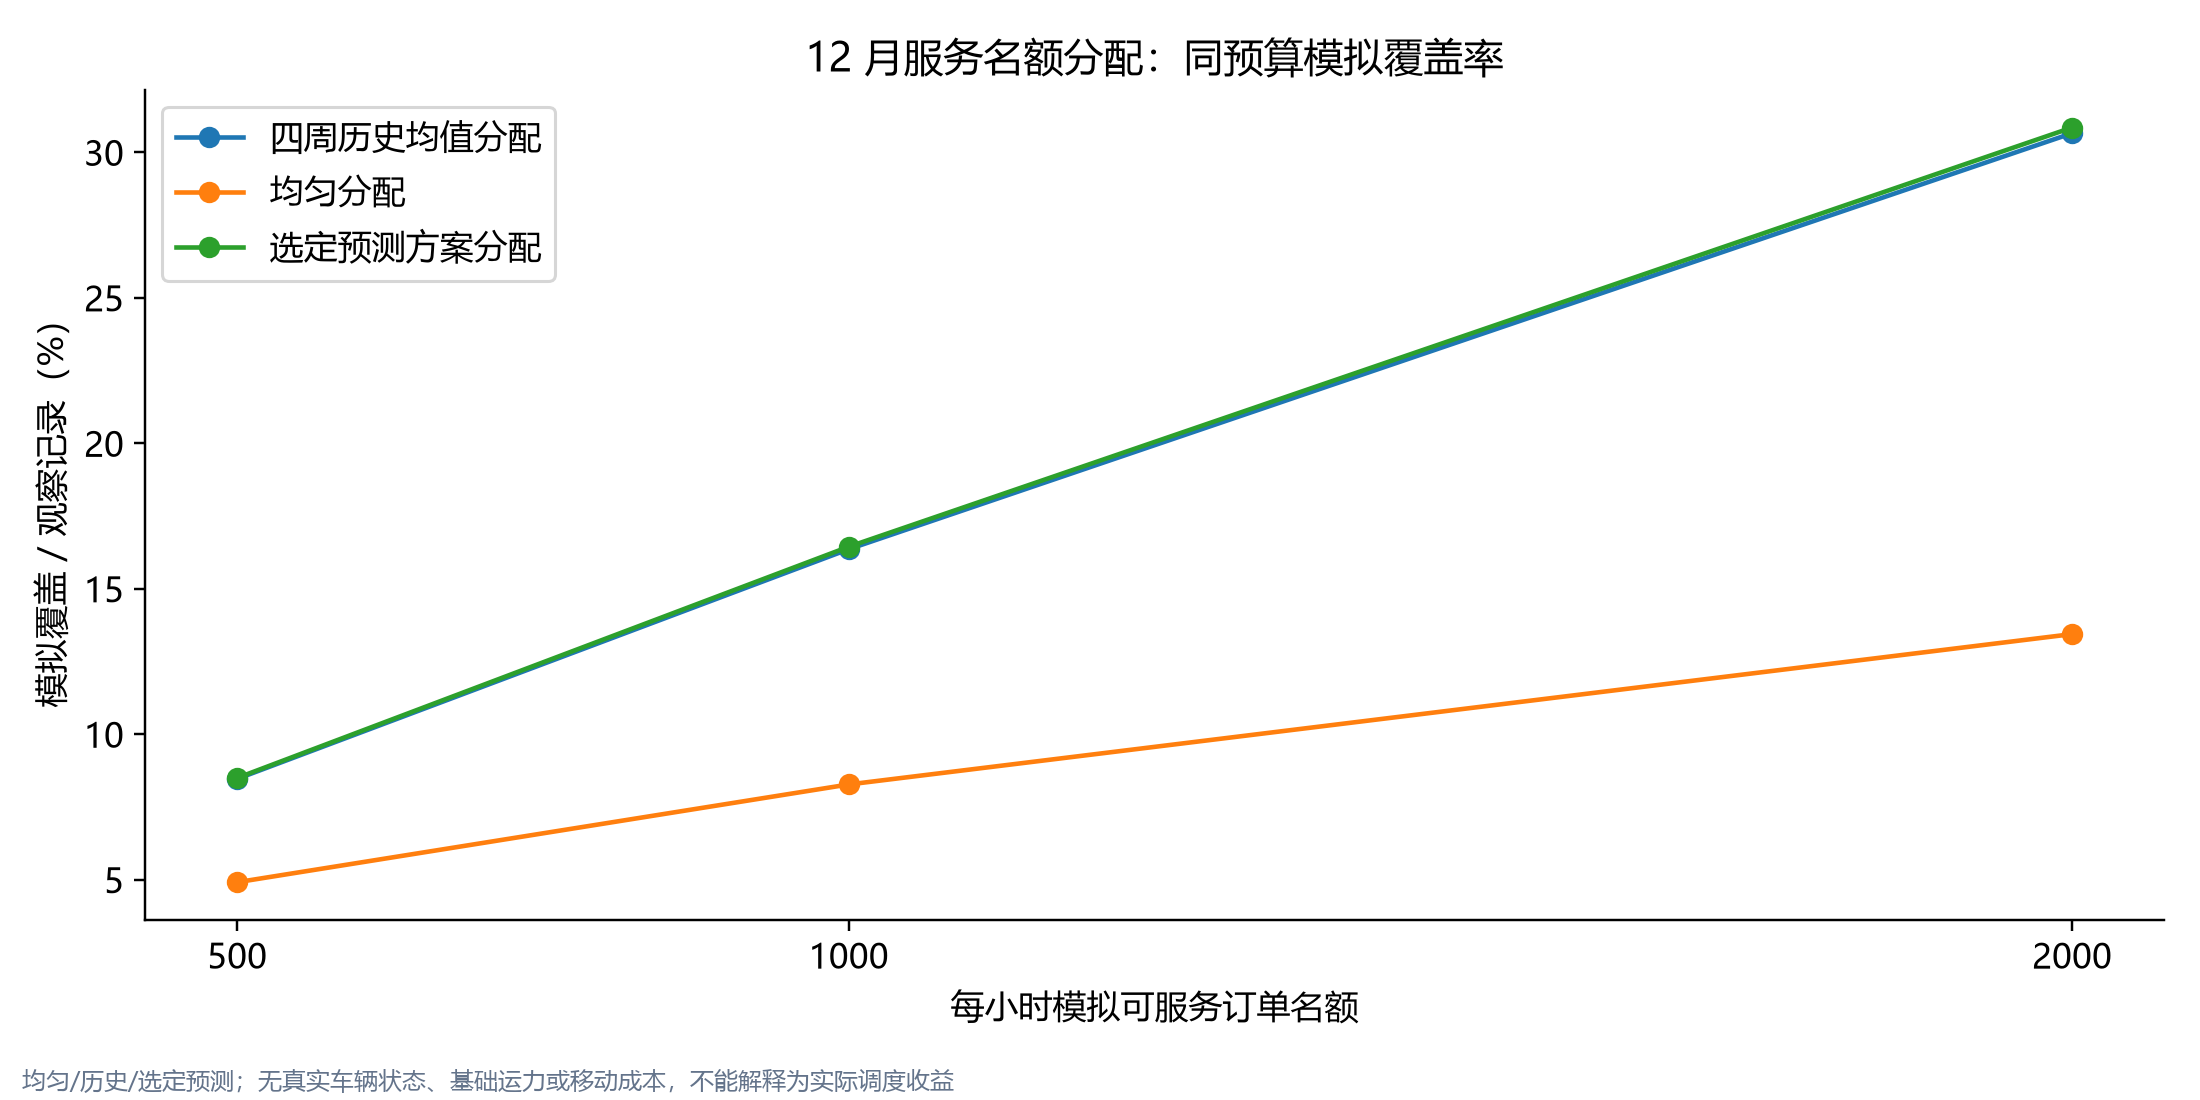

In [5]:
from IPython.display import Image,display
display(Image(filename=str(ROOT/'reports/figures/09_dispatch_simulation.png'),width=900))

看板的区域筛选只显示全区域既定分配的子集，不重新分配总名额。未建模车辆途中状态、跨区行驶和基础运力，所以不能将覆盖差额写成企业实际成本节省。